# Boundary Conditions for Isafjardardjup (299x315 Grid)

This notebook creates boundary condition files for the Isafjardardju fjord simulation.

## Grid Configuration
- Bathymetry: `Isafjardardjup_bathymetry299x315.nc`
- Grid dimensions: 299 x 315 (downsampled by factor of 2)
- Vertical levels: 29 layers with **negative** z-coordinates (Oceananigans convention)

## Boundary Data Sources
1. **Ocean boundaries**: CMEMS reanalysis data
2. **River inputs**: 4 major rivers (Þverá, Hvalá, Dynjandisá, Vatnsdalsá)

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.ndimage import gaussian_filter, label
from scipy.spatial import cKDTree
from scipy.interpolate import interp1d

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Load Bathymetry Grid

Load the new bathymetry file to get grid dimensions and coordinates.

In [2]:
# Load bathymetry file
bathy_path = r"C:/Users/fisa/FjordsSim_data/isafjardardjup/Isafjardardjup_bathymetry299x315.nc"
bathy = xr.open_dataset(bathy_path)
print("=== Bathymetry File ===")
print(bathy)
print(f"\nGrid dimensions: {bathy.dims}")

=== Bathymetry File ===
<xarray.Dataset> Size: 759kB
Dimensions:  (y: 315, x: 299, z: 30)
Coordinates:
    lat      (y) float64 3kB ...
    lon      (x) float64 2kB ...
Dimensions without coordinates: y, x, z
Data variables:
    h        (y, x) float64 753kB ...
    z_faces  (z) float64 240B ...
Attributes:
    title:        Isafjardardju Bathymetry for Oceananigans
    created:      2025-11-15
    description:  Bathymetry data for FjordsSim.jl ImmersedBoundaryGrid function

Grid dimensions: FrozenMappingWarningOnValuesAccess({'y': 315, 'x': 299, 'z': 30})


In [3]:
# Extract grid parameters
# Note: h is stored as negative values (depth below surface)
# We negate it to get positive depth for visualization
grid_depth = -bathy['h'].values  # Make positive for visualization
lat_centers = bathy['lat'].values
lon_centers = bathy['lon'].values
z_faces = bathy['z_faces'].values  # Already negative, ordered from deepest to surface

# Grid dimensions
nx = len(lon_centers)
ny = len(lat_centers)
nz = len(z_faces) - 1  # Number of vertical layers

print(f"Grid size: {nx} x {ny} x {nz}")
print(f"Latitude range: {lat_centers.min():.4f}°N to {lat_centers.max():.4f}°N")
print(f"Longitude range: {lon_centers.min():.4f}°E to {lon_centers.max():.4f}°E")
print(f"Depth range: {grid_depth[grid_depth > 0].min():.1f}m to {grid_depth.max():.1f}m")
print(f"Vertical levels: {nz} layers (z_faces: {z_faces[0]:.0f}m to {z_faces[-1]:.0f}m)")
print(f"Wet cells: {np.sum(grid_depth > 0)} ({100*np.sum(grid_depth > 0)/(nx*ny):.1f}%)")

Grid size: 299 x 315 x 29
Latitude range: 65.7600°N to 66.3880°N
Longitude range: -23.4920°E to -22.3000°E
Depth range: 10.0m to 195.1m
Vertical levels: 29 layers (z_faces: -190m to 0m)
Wet cells: 28286 (30.0%)


In [4]:
# Calculate z_centers from z_faces
# z_faces are ordered from deepest (most negative) to surface (0)
z_centers = [(z_faces[i] + z_faces[i+1]) / 2 for i in range(len(z_faces) - 1)]
print(f"z_centers ({len(z_centers)} levels):")
print(f"  Deepest: {[f'{z:.1f}' for z in z_centers[:5]]}")
print(f"  Surface: {[f'{z:.1f}' for z in z_centers[-5:]]}")

z_centers (29 levels):
  Deepest: ['-180.0', '-160.0', '-145.0', '-135.0', '-125.0']
  Surface: ['-4.5', '-3.5', '-2.5', '-1.5', '-0.5']


## 2. Visualize Bathymetry

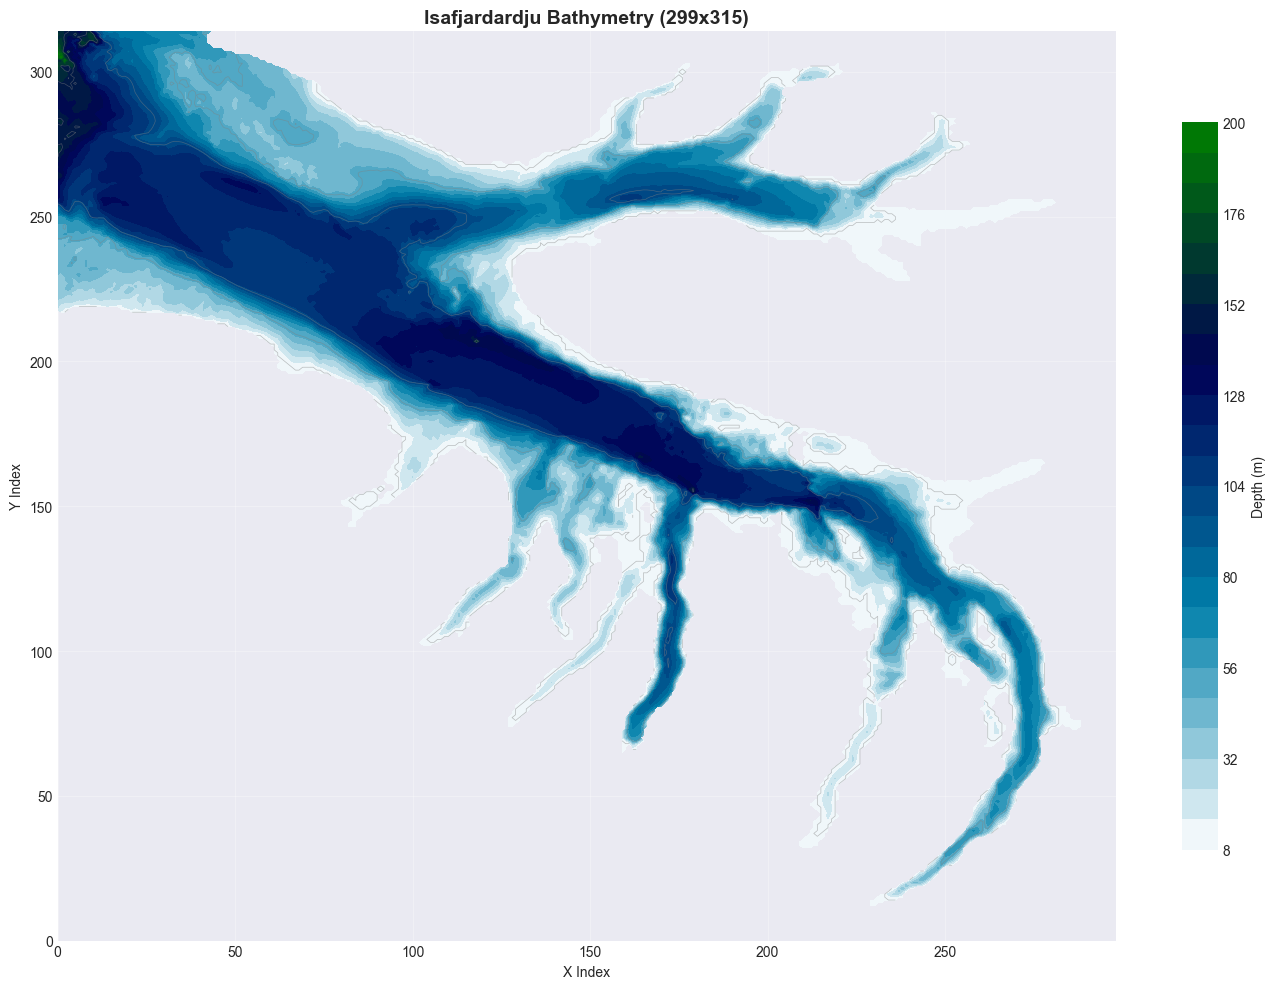

In [5]:
# Plot bathymetry
fig, ax = plt.subplots(figsize=(14, 10))
depth_plot = np.where(grid_depth == 0, np.nan, grid_depth)
cf = ax.contourf(depth_plot, levels=25, cmap='ocean_r')
ax.contour(depth_plot, levels=[10, 50, 100, 150], colors='gray', alpha=0.5, linewidths=0.5)
plt.colorbar(cf, ax=ax, label='Depth (m)', shrink=0.8)
ax.set_title('Isafjardardju Bathymetry (299x315)', fontsize=14, fontweight='bold')
ax.set_xlabel('X Index')
ax.set_ylabel('Y Index')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Load CMEMS Ocean Data

Load CMEMS reanalysis data for ocean boundary conditions.

In [6]:
# Load CMEMS data (adjust filename as needed)
cmems_file = "P1D-m_1745438014042.nc"
cmems = xr.open_dataset(cmems_file).isel(depth=slice(0, 21))
print("=== CMEMS Data ===")
print(cmems)
print(f"\nTime range: {cmems.time.values[0]} to {cmems.time.values[-1]}")
print(f"Vertical levels: {len(cmems.depth)} ({cmems.depth.min().values:.1f}m to {cmems.depth.max().values:.1f}m)")

=== CMEMS Data ===
<xarray.Dataset> Size: 255MB
Dimensions:      (time: 366, depth: 21, latitude: 25, longitude: 81)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1992-01-01
  * depth        (depth) float32 84B -0.0 2.0 4.0 6.0 ... 175.0 200.0 250.0
  * latitude     (latitude) float32 100B 64.0 64.12 64.25 ... 66.75 66.88 67.0
  * longitude    (longitude) float32 324B -28.0 -27.88 -27.75 ... -18.12 -18.0
Data variables:
    so           (time, depth, latitude, longitude) float32 62MB ...
    thetao       (time, depth, latitude, longitude) float32 62MB ...
    vxo          (time, depth, latitude, longitude) float32 62MB ...
    model_depth  (latitude, longitude) float32 8kB ...
    vyo          (time, depth, latitude, longitude) float32 62MB ...
    zos          (time, latitude, longitude) float32 3MB ...
    sithick      (time, latitude, longitude) float32 3MB ...
Attributes:
    Conventions:       CF-1.11
    title:             Arctic Ocean Physics 

## 4. Extract Boundary Conditions from CMEMS

Extract ocean boundary conditions at the western edge (open ocean) of the domain.

In [7]:
# Define boundary location (westernmost longitude for open ocean)
lon_boundary = -25.0  # Adjust based on CMEMS coverage

# Subset CMEMS data for boundary
cmems_boundary = cmems.sel(longitude=lon_boundary, latitude=lat_centers, method='nearest')

print(f"Boundary location: {lon_boundary}°E")
print(f"Extracted data shape: time={len(cmems_boundary.time)}, depth={len(cmems_boundary.depth)}, lat={len(cmems_boundary.latitude)}")

Boundary location: -25.0°E
Extracted data shape: time=366, depth=21, lat=315


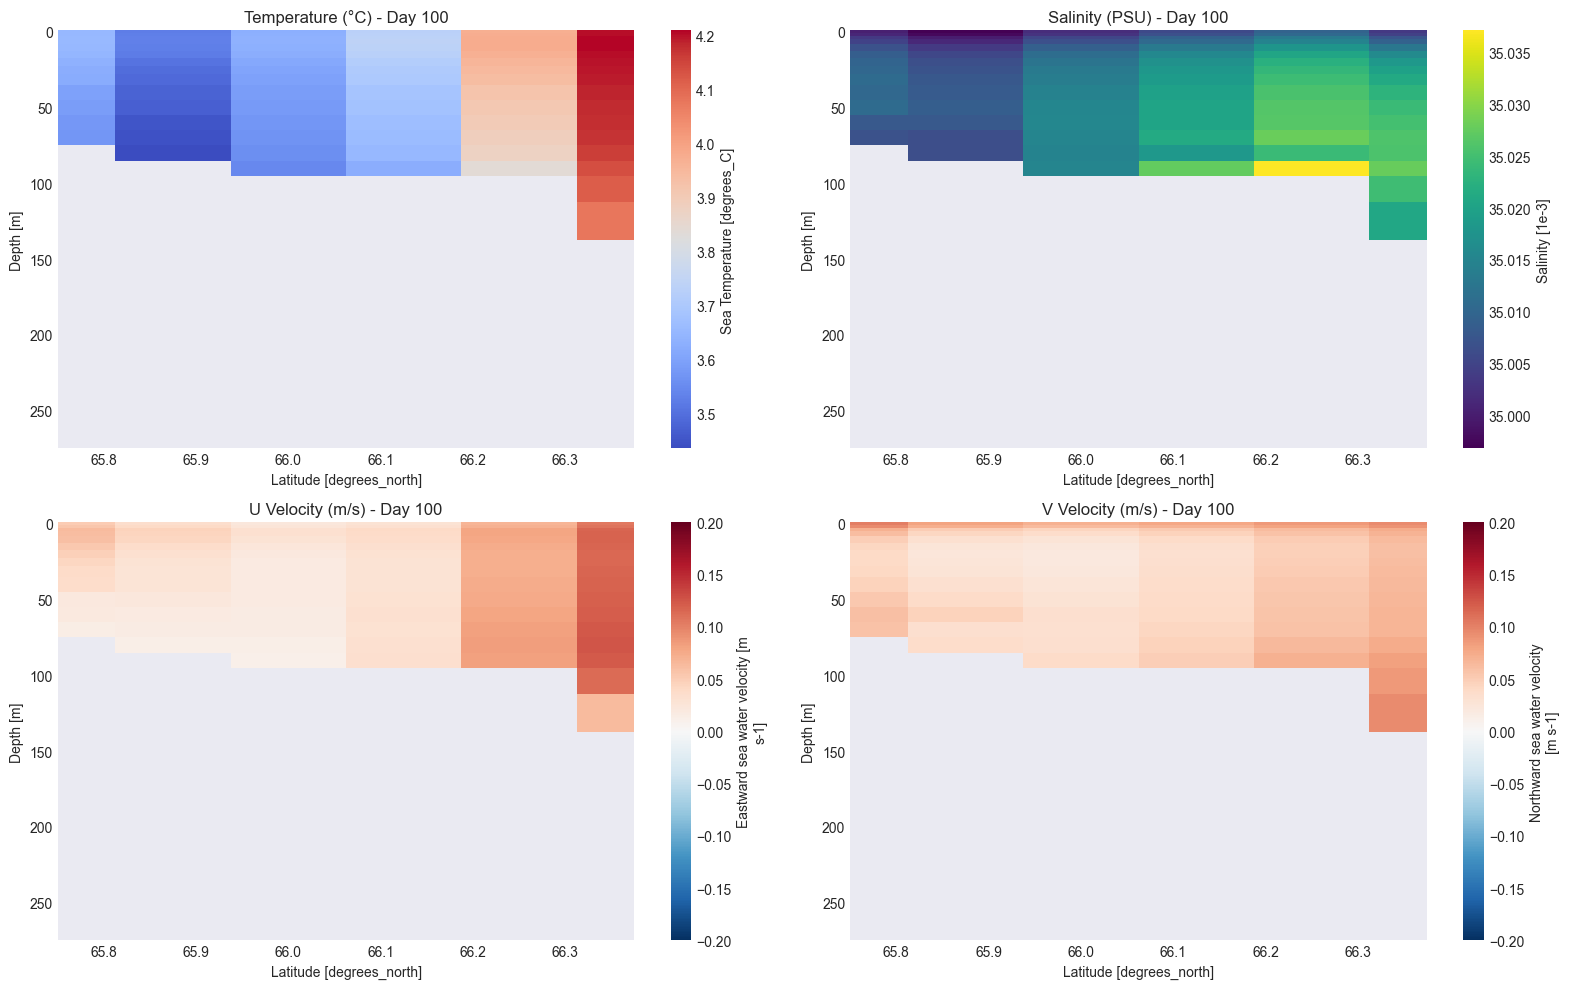

In [8]:
# Visualize boundary conditions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Temperature
cmems_boundary.thetao.isel(time=100).plot(ax=axes[0, 0], cmap='coolwarm')
axes[0, 0].set_title('Temperature (°C) - Day 100')
axes[0, 0].invert_yaxis()

# Salinity
cmems_boundary.so.isel(time=100).plot(ax=axes[0, 1], cmap='viridis')
axes[0, 1].set_title('Salinity (PSU) - Day 100')
axes[0, 1].invert_yaxis()

# U velocity
cmems_boundary.vxo.isel(time=100).plot(ax=axes[1, 0], cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1, 0].set_title('U Velocity (m/s) - Day 100')
axes[1, 0].invert_yaxis()

# V velocity
cmems_boundary.vyo.isel(time=100).plot(ax=axes[1, 1], cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1, 1].set_title('V Velocity (m/s) - Day 100')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## 5. Interpolate to Model Grid

Interpolate CMEMS data to the model's vertical grid (z_centers).

In [9]:
cmems_boundary

<xarray.Dataset> Size: 40MB
Dimensions:      (time: 366, depth: 21, latitude: 315)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1992-01-01
  * depth        (depth) float32 84B -0.0 2.0 4.0 6.0 ... 175.0 200.0 250.0
  * latitude     (latitude) float32 1kB 65.75 65.75 65.75 ... 66.38 66.38 66.38
    longitude    float32 4B -25.0
Data variables:
    so           (time, depth, latitude) float32 10MB ...
    thetao       (time, depth, latitude) float32 10MB ...
    vxo          (time, depth, latitude) float32 10MB ...
    model_depth  (latitude) float32 1kB ...
    vyo          (time, depth, latitude) float32 10MB ...
    zos          (time, latitude) float32 461kB ...
    sithick      (time, latitude) float32 461kB ...
Attributes:
    Conventions:       CF-1.11
    title:             Arctic Ocean Physics Reanalysis
    institution:       NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:            NERSC-HYCOM model fields
    history:           20220829:Created by program hyc2proj, version V0.3
    references:        http://topaz.nersc.no
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  ARCTIC_MULTIYEAR_PHY_002_003
    subset:datasetId:  cmems_mod_arc_phy_my_topaz4_P1D-m_202211
    subset:date:       2025-04-23T19:53:34.043Z

In [10]:
# Prepare CMEMS data for interpolation
if cmems_boundary.depth.values[1] > 0:
    cmems_boundary['depth'] = -cmems_boundary.depth

# Rename variables
ds_interp = cmems_boundary.rename({
    'longitude': 'Nx',
    'latitude': 'Ny', 
    'depth': 'Nz',
    'thetao': 'T',
    'so': 'S',
    'vxo': 'u',
    'vyo': 'v'
})

print("Interpolating to model vertical grid...")
print(f"Original depth levels: {len(ds_interp.Nz)}")
print(f"Target depth levels (z_centers): {len(z_centers)}")
print(f"z_centers range: {z_centers[0]:.1f}m to {z_centers[-1]:.1f}m")

Interpolating to model vertical grid...
Original depth levels: 21
Target depth levels (z_centers): 29
z_centers range: -180.0m to -0.5m


In [11]:
# Interpolate to z_centers
# Note: This may take a minute
ds_interp = ds_interp.interp(Nz=z_centers, method='linear')

# Forward fill NaN values at depth (below CMEMS coverage)
ds_interp = ds_interp.bfill(dim='Nz')

print("✓ Interpolation complete")
print(f"Interpolated shape: {ds_interp.dims}")

✓ Interpolation complete
Interpolated shape: FrozenMappingWarningOnValuesAccess({'time': 366, 'Ny': 315, 'Nz': 29})


In [12]:
ds_interp

<xarray.Dataset> Size: 108MB
Dimensions:      (time: 366, Ny: 315, Nz: 29)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1992-01-01
  * Ny           (Ny) float32 1kB 65.75 65.75 65.75 65.75 ... 66.38 66.38 66.38
  * Nz           (Nz) float64 232B -180.0 -160.0 -145.0 ... -2.5 -1.5 -0.5
    Nx           float32 4B -25.0
Data variables:
    S            (time, Nz, Ny) float64 27MB 35.03 35.03 35.03 ... 34.92 34.92
    T            (time, Nz, Ny) float64 27MB 4.7 4.7 4.7 ... 4.185 4.185 4.185
    u            (time, Nz, Ny) float64 27MB 0.02076 0.02076 ... 0.02565 0.02565
    model_depth  (Ny) float32 1kB ...
    v            (time, Nz, Ny) float64 27MB 0.03575 0.03575 ... -0.004279
    zos          (time, Ny) float32 461kB ...
    sithick      (time, Ny) float32 461kB ...
Attributes:
    Conventions:       CF-1.11
    title:             Arctic Ocean Physics Reanalysis
    institution:       NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    source:            NERSC-HYCOM model fields
    history:           20220829:Created by program hyc2proj, version V0.3
    references:        http://topaz.nersc.no
    subset:source:     ARCO data downloaded from the Marine Data Store using ...
    subset:productId:  ARCTIC_MULTIYEAR_PHY_002_003
    subset:datasetId:  cmems_mod_arc_phy_my_topaz4_P1D-m_202211
    subset:date:       2025-04-23T19:53:34.043Z

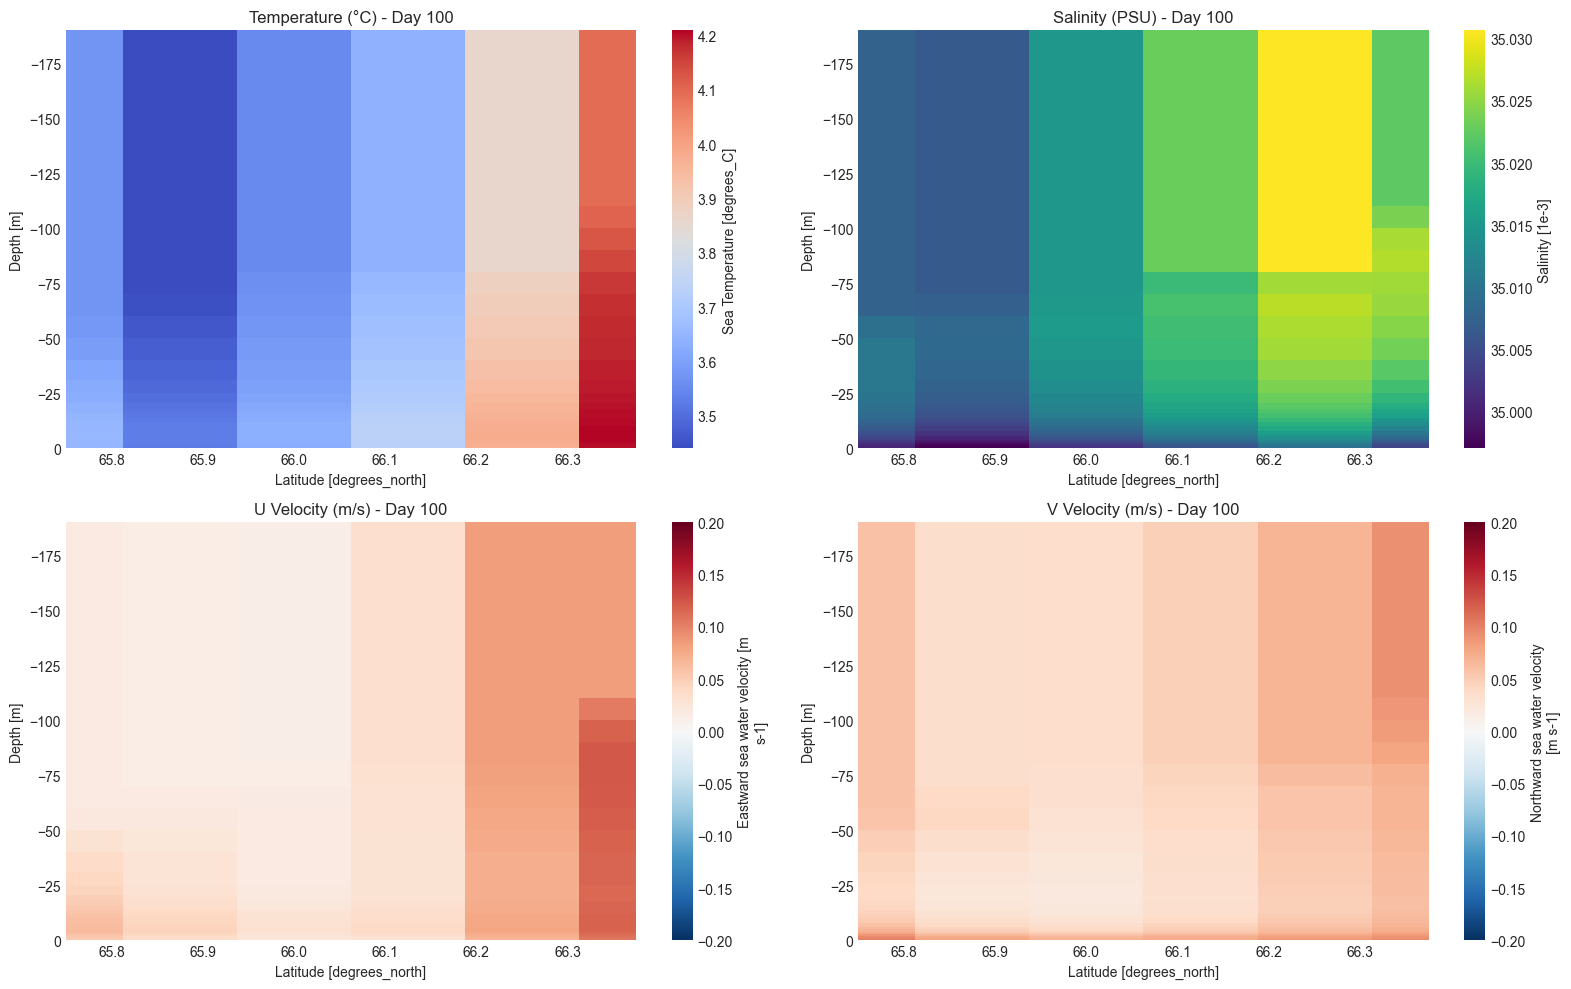

In [13]:
# Visualize boundary conditions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Temperature
ds_interp.T.isel(time=100).plot(ax=axes[0, 0], cmap='coolwarm')
axes[0, 0].set_title('Temperature (°C) - Day 100')
axes[0, 0].invert_yaxis()

# Salinity
ds_interp.S.isel(time=100).plot(ax=axes[0, 1], cmap='viridis')
axes[0, 1].set_title('Salinity (PSU) - Day 100')
axes[0, 1].invert_yaxis()

# U velocity
ds_interp.u.isel(time=100).plot(ax=axes[1, 0], cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1, 0].set_title('U Velocity (m/s) - Day 100')
axes[1, 0].invert_yaxis()

# V velocity
ds_interp.v.isel(time=100).plot(ax=axes[1, 1], cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1, 1].set_title('V Velocity (m/s) - Day 100')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## 6. Prepare Boundary Arrays

Create arrays for boundary conditions on the model grid.

In [14]:
# Number of time steps (use subset for testing)
nt = len(ds_interp.time)
print(f"Time steps: {nt}")

# Initialize arrays
print(f"\nInitializing arrays with shape:")
print(f"  T, S: (nt={nt}, nz={nz}, ny={ny}, nx={nx})")
print(f"  u: (nt={nt}, nz={nz}, ny={ny}, nx+1={nx+1})")
print(f"  v: (nt={nt}, nz={nz}, ny+1={ny+1}, nx={nx})")

np_temp = np.zeros((nt, nz, ny, nx), dtype=np.float32)
np_salt = np.zeros((nt, nz, ny, nx), dtype=np.float32)
np_u = np.zeros((nt, nz, ny, nx+1), dtype=np.float32)
np_v = np.zeros((nt, nz, ny+1, nx), dtype=np.float32)

print("✓ Arrays initialized")

Time steps: 366

Initializing arrays with shape:
  T, S: (nt=366, nz=29, ny=315, nx=299)
  u: (nt=366, nz=29, ny=315, nx+1=300)
  v: (nt=366, nz=29, ny+1=316, nx=299)
✓ Arrays initialized


In [15]:
# Extract and smooth boundary data
print("Applying Gaussian smoothing...")
tcmems = gaussian_filter(ds_interp['T'].values, sigma=(0.2, 0.1, 15))
scmems = gaussian_filter(ds_interp['S'].values, sigma=(0.2, 0.1, 15))
ucmems = gaussian_filter(ds_interp['u'].values, sigma=(0.2, 0.1, 15))
vcmems = gaussian_filter(ds_interp['v'].values, sigma=(0.2, 0.1, 15))

print(f"✓ Smoothing complete")
print(f"  T range: {tcmems.min():.2f} to {tcmems.max():.2f} °C")
print(f"  S range: {scmems.min():.2f} to {scmems.max():.2f} PSU")
print(f"  u range: {ucmems.min():.3f} to {ucmems.max():.3f} m/s")
print(f"  v range: {vcmems.min():.3f} to {vcmems.max():.3f} m/s")

Applying Gaussian smoothing...
✓ Smoothing complete
  T range: 3.30 to 12.25 °C
  S range: 33.61 to 35.09 PSU
  u range: -0.506 to 0.317 m/s
  v range: -0.335 to 0.406 m/s


In [16]:
# Apply boundary conditions
# Left boundary (x=0, western edge - open ocean)
np_temp[:, :, :, 0] = tcmems
np_salt[:, :, :, 0] = scmems
np_u[:, :, :, 0] = ucmems

# Extend v to include boundary face
vcmems_extended = np.concatenate((vcmems, vcmems[:, :, -1:]), axis=2)
np_v[:, :, :, 0] = vcmems_extended

# Northern boundary (y=-1, northern edge)
# Repeat last latitude value across all longitudes
np_temp[:, :, -1, :] = np.repeat(tcmems[:, :, -1:], nx, axis=2)
np_salt[:, :, -1, :] = np.repeat(scmems[:, :, -1:], nx, axis=2)
np_u[:, :, -1, :] = np.repeat(ucmems[:, :, -1:], nx+1, axis=2)
np_v[:, :, -1, :] = np.repeat(vcmems_extended[:, :, -1:], nx, axis=2)

print("✓ Boundary conditions applied")

✓ Boundary conditions applied


In [17]:
np_salt[:, :, -1, :]

array([[[34.954197, 34.954197, 34.954197, ..., 34.954197, 34.954197,
         34.954197],
        [34.954197, 34.954197, 34.954197, ..., 34.954197, 34.954197,
         34.954197],
        [34.954197, 34.954197, 34.954197, ..., 34.954197, 34.954197,
         34.954197],
        ...,
        [34.937737, 34.937737, 34.937737, ..., 34.937737, 34.937737,
         34.937737],
        [34.93697 , 34.93697 , 34.93697 , ..., 34.93697 , 34.93697 ,
         34.93697 ],
        [34.936573, 34.936573, 34.936573, ..., 34.936573, 34.936573,
         34.936573]],

       [[34.9559  , 34.9559  , 34.9559  , ..., 34.9559  , 34.9559  ,
         34.9559  ],
        [34.9559  , 34.9559  , 34.9559  , ..., 34.9559  , 34.9559  ,
         34.9559  ],
        [34.9559  , 34.9559  , 34.9559  , ..., 34.9559  , 34.9559  ,
         34.9559  ],
        ...,
        [34.95128 , 34.95128 , 34.95128 , ..., 34.95128 , 34.95128 ,
         34.95128 ],
        [34.95056 , 34.95056 , 34.95056 , ..., 34.95056 , 34.95056 ,
   

## 7. Load River Data

Load river information from NetCDF file containing discharge data and locations.

In [18]:
# Load river data from NetCDF file
river_file = r"C:\Users\fisa\Documents\fjordssim-notebooks\Isafjardardjup\isafjardardjup_rivers_wfs.nc"
rivers_ds = xr.open_dataset(river_file)

print("=== River Dataset ===")
print(rivers_ds)
print(f"\nNumber of rivers: {len(rivers_ds.river)}")
print(f"Time range: {len(rivers_ds.time)} days")

# Extract river information
river_names = [name.strip() for name in rivers_ds.river_name.values]
river_lats = rivers_ds.river_lat.values
river_lons = rivers_ds.river_lon.values
river_lengths = rivers_ds.river_length.values

# Filter out rivers with missing location data
valid_rivers = ~(np.isnan(river_lats) | np.isnan(river_lons))
river_names = [name for i, name in enumerate(river_names) if valid_rivers[i]]
river_lats = river_lats[valid_rivers]
river_lons = river_lons[valid_rivers]
river_indices = np.where(valid_rivers)[0]

print(f"\nRivers with valid locations: {len(river_names)}")
print("\n=== River Locations (first 10) ===")
for i, (name, lat, lon) in enumerate(zip(river_names[:10], river_lats[:10], river_lons[:10])):
    print(f"{name:30s}: {lat:7.4f}°N, {lon:8.4f}°E")

=== River Dataset ===
<xarray.Dataset> Size: 4MB
Dimensions:          (river: 60, time: 3653)
Coordinates:
  * river            (river) int64 480B 0 1 2 3 4 5 6 7 ... 53 54 55 56 57 58 59
  * time             (time) datetime64[ns] 29kB 2014-10-01 ... 2024-09-30
    river_lon        (river) float64 480B ...
    river_lat        (river) float64 480B ...
Data variables:
    river_name       (river) <U17 4kB ...
    river_discharge  (time, river) float64 2MB ...
    river_transport  (time, river) float64 2MB ...
    river_length     (river) float64 480B ...
Attributes:
    title:                River forcing for Isafjardardjup, Iceland
    description:          River discharge data scaled from Þverá observations...
    institution:          Iceland Ocean Model
    source:               Þverá observations from observations/rivers_Q.xlsx ...
    history:              Created 2025-11-03 11:29:58
    references:           Discharge scaling method: length; WFS data: https:/...
    Conventions: 

In [35]:
lat_centers

array([65.76 , 65.762, 65.764, 65.766, 65.768, 65.77 , 65.772, 65.774,
       65.776, 65.778, 65.78 , 65.782, 65.784, 65.786, 65.788, 65.79 ,
       65.792, 65.794, 65.796, 65.798, 65.8  , 65.802, 65.804, 65.806,
       65.808, 65.81 , 65.812, 65.814, 65.816, 65.818, 65.82 , 65.822,
       65.824, 65.826, 65.828, 65.83 , 65.832, 65.834, 65.836, 65.838,
       65.84 , 65.842, 65.844, 65.846, 65.848, 65.85 , 65.852, 65.854,
       65.856, 65.858, 65.86 , 65.862, 65.864, 65.866, 65.868, 65.87 ,
       65.872, 65.874, 65.876, 65.878, 65.88 , 65.882, 65.884, 65.886,
       65.888, 65.89 , 65.892, 65.894, 65.896, 65.898, 65.9  , 65.902,
       65.904, 65.906, 65.908, 65.91 , 65.912, 65.914, 65.916, 65.918,
       65.92 , 65.922, 65.924, 65.926, 65.928, 65.93 , 65.932, 65.934,
       65.936, 65.938, 65.94 , 65.942, 65.944, 65.946, 65.948, 65.95 ,
       65.952, 65.954, 65.956, 65.958, 65.96 , 65.962, 65.964, 65.966,
       65.968, 65.97 , 65.972, 65.974, 65.976, 65.978, 65.98 , 65.982,
      

In [37]:
# Find nearest grid cells for rivers
valid_mask = grid_depth > 0
valid_indices = np.argwhere(valid_mask)

# Create 2D lon/lat grids
lon_grid_2d, lat_grid_2d = np.meshgrid(lon_centers, lat_centers)
valid_lons = lon_grid_2d[valid_mask]
valid_lats = lat_grid_2d[valid_mask]

# Build KD-tree
tree = cKDTree(np.column_stack([valid_lats, valid_lons]))

# Find nearest grid points for each river
xrivers = []
yrivers = []
river_grid_indices = []

print("\n=== River Grid Mapping ===")
for i, (name, rlat, rlon) in enumerate(zip(river_names, river_lats, river_lons)):
    dist, idx = tree.query([rlat, rlon])
    x_idx, y_idx = valid_indices[idx]
    xrivers.append(x_idx)
    yrivers.append(y_idx)
    river_grid_indices.append(i)
    
    if i < 10:  # Print first 10
        print(f"{name:30s}: Grid ({x_idx:3d}, {y_idx:3d}), Distance: {dist:.4f}°, Depth: {grid_depth[x_idx, y_idx]:6.1f}m")

print(f"\n✓ Mapped {len(xrivers)} rivers to grid")


=== River Grid Mapping ===
Selá 1                        : Grid (142, 257), Distance: 0.0045°, Depth:   10.0m
Dalsá                         : Grid (172, 226), Distance: 0.0019°, Depth:   10.0m
Bjarnadalsá                   : Grid (217,  21), Distance: 0.1976°, Depth:   10.0m
Þverá                         : Grid ( 73, 287), Distance: 0.0017°, Depth:   10.0m
Jökulá/Landá                  : Grid (230, 233), Distance: 0.0014°, Depth:   10.0m
Bjarnarfjarðará               : Grid (255, 282), Distance: 0.3648°, Depth:   10.0m
Hafnardalsá                   : Grid ( 88, 278), Distance: 0.0017°, Depth:   10.0m
Mórilla                       : Grid (163, 274), Distance: 0.0021°, Depth:   10.0m
Hestá                         : Grid (151,  80), Distance: 0.2059°, Depth:   10.0m
Blævardalsá                   : Grid (107, 275), Distance: 0.0018°, Depth:   10.3m

✓ Mapped 60 rivers to grid


In [38]:
xrivers

[np.int64(142),
 np.int64(172),
 np.int64(217),
 np.int64(73),
 np.int64(230),
 np.int64(255),
 np.int64(88),
 np.int64(163),
 np.int64(151),
 np.int64(107),
 np.int64(242),
 np.int64(255),
 np.int64(255),
 np.int64(217),
 np.int64(103),
 np.int64(270),
 np.int64(255),
 np.int64(151),
 np.int64(218),
 np.int64(217),
 np.int64(255),
 np.int64(255),
 np.int64(289),
 np.int64(217),
 np.int64(169),
 np.int64(183),
 np.int64(301),
 np.int64(231),
 np.int64(255),
 np.int64(277),
 np.int64(177),
 np.int64(104),
 np.int64(255),
 np.int64(198),
 np.int64(255),
 np.int64(217),
 np.int64(141),
 np.int64(242),
 np.int64(90),
 np.int64(256),
 np.int64(255),
 np.int64(150),
 np.int64(217),
 np.int64(189),
 np.int64(135),
 np.int64(216),
 np.int64(127),
 np.int64(262),
 np.int64(270),
 np.int64(74),
 np.int64(255),
 np.int64(143),
 np.int64(303),
 np.int64(152),
 np.int64(286),
 np.int64(303),
 np.int64(72),
 np.int64(196),
 np.int64(217),
 np.int64(73)]

In [39]:
depth_plot.shape

(315, 299)

✓ Plotted 60 river locations


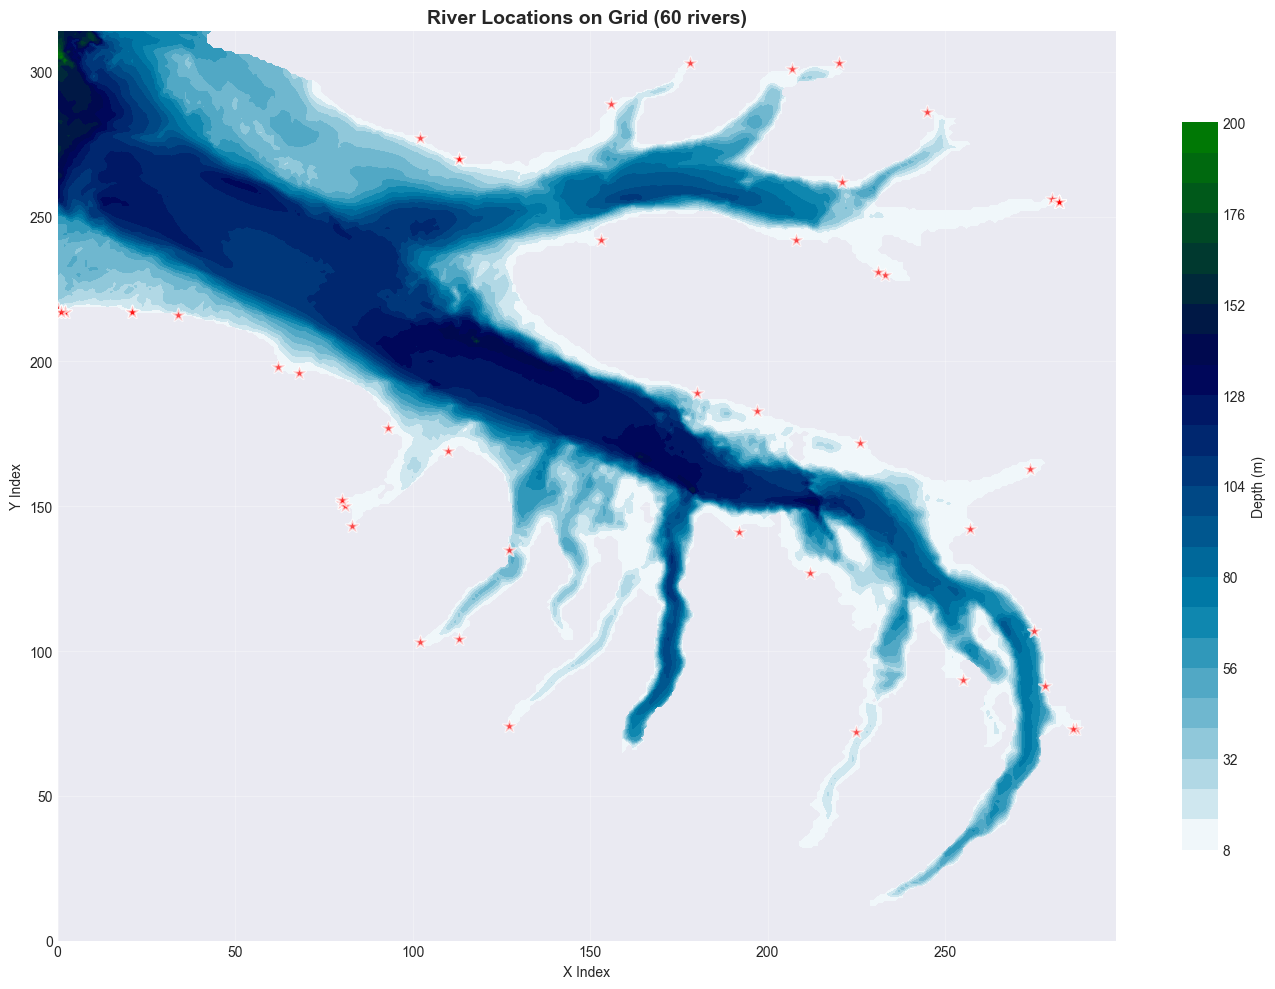

In [42]:
# Visualize river locations
fig, ax = plt.subplots(figsize=(14, 10))
cf = ax.contourf(depth_plot, levels=25, cmap='ocean_r')

# Plot all rivers
for i, (x, y, name) in enumerate(zip(xrivers, yrivers, river_names)):
    ax.scatter(y, x, c='red', s=100, marker='*', edgecolors='white', linewidths=1.5, zorder=10, alpha=0.7)

# Label only major rivers (top 5 by length)
#if len(river_lengths) > 0:
#    major_rivers_idx = np.argsort(river_lengths[valid_rivers])[-5:]
#    for idx in major_rivers_idx:
#        if idx < len(xrivers):
#            x, y = xrivers[idx], yrivers[idx]
#            name = river_names[idx]
#            ax.text(y+5, x+5, name[:15], fontsize=9, fontweight='bold', color='red',
#                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.colorbar(cf, ax=ax, label='Depth (m)', shrink=0.8)
ax.set_title(f'River Locations on Grid ({len(xrivers)} rivers)', fontsize=14, fontweight='bold')
ax.set_xlabel('X Index')
ax.set_ylabel('Y Index')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('river_locations_model.png', bbox_inches='tight', dpi=300)
print(f"✓ Plotted {len(xrivers)} river locations")

## 8. Calculate River Discharge Statistics

In [43]:
# Calculate mean discharge for each river
river_discharge = rivers_ds.river_discharge.values  # Shape: (time, river)

# Extract discharge for valid rivers only
river_discharge_valid = river_discharge[:, river_indices]

# Calculate mean discharge (handling fill values)
Q_rivers = []
for i, idx in enumerate(river_indices):
    discharge_data = river_discharge[:, idx]
    # Filter out fill values (-999.0) and NaN
    valid_discharge = discharge_data[(discharge_data != -999.0) & ~np.isnan(discharge_data)]
    
    if len(valid_discharge) > 0:
        mean_Q = np.mean(valid_discharge)
    else:
        mean_Q = 0.0
    
    Q_rivers.append(mean_Q)

Q_rivers = np.array(Q_rivers)

print("=== River Discharge Statistics ===")
print(f"Total rivers: {len(Q_rivers)}")
print(f"Rivers with discharge > 0: {np.sum(Q_rivers > 0)}")
print(f"Total mean discharge: {Q_rivers.sum():.2f} m³/s")
print(f"\nTop 10 rivers by discharge:")
top_10_idx = np.argsort(Q_rivers)[-10:][::-1]
for idx in top_10_idx:
    if idx < len(river_names):
        print(f"  {river_names[idx]:30s}: {Q_rivers[idx]:6.2f} m³/s")

=== River Discharge Statistics ===
Total rivers: 60
Rivers with discharge > 0: 60
Total mean discharge: 82.16 m³/s

Top 10 rivers by discharge:
  Selá 1                        :   2.97 m³/s
  Dalsá                         :   2.84 m³/s
  Bjarnadalsá                   :   2.32 m³/s
  Þverá                         :   2.31 m³/s
  Jökulá/Landá                  :   2.24 m³/s
  Bjarnarfjarðará               :   2.21 m³/s
  Hafnardalsá                   :   2.18 m³/s
  Mórilla                       :   1.92 m³/s
  Hestá                         :   1.91 m³/s
  Blævardalsá                   :   1.87 m³/s


## 9. Apply River Freshwater Input

In [45]:
# Set salinity to 0 at river input locations (freshwater)
for x, y in zip(xrivers, yrivers):
    np_salt[:, :, x, y] = 0.0

print("✓ River freshwater inputs applied (salinity = 0 at river cells)")

✓ River freshwater inputs applied (salinity = 0 at river cells)


## 10. Relaxation Coefficients (Lambda)

Define relaxation timescales for boundary conditions.

In [46]:
# Initialize lambda arrays
lambda_T = np.zeros((nt, nz, ny, nx), dtype=np.float32)
lambda_S = np.zeros((nt, nz, ny, nx), dtype=np.float32)
lambda_u = np.zeros((nt, nz, ny, nx+1), dtype=np.float32)
lambda_v = np.zeros((nt, nz, ny+1, nx), dtype=np.float32)

# Ocean boundaries: 10-day relaxation timescale
lambda_ocean = 1.0 / (60 * 60 * 24 * 10)  # 1/(10 days in seconds)

# Left boundary (x=0, western ocean)
lambda_T[:, :, :, 0] = lambda_ocean
lambda_S[:, :, :, 0] = lambda_ocean
lambda_u[:, :, :, 0] = lambda_ocean
lambda_v[:, :, :, 0] = lambda_ocean

# Northern boundary (y=-1, northern ocean)
lambda_T[:, :, -1, :] = lambda_ocean
lambda_S[:, :, -1, :] = lambda_ocean
lambda_u[:, :, -1, :] = lambda_ocean
lambda_v[:, :, -1, :] = lambda_ocean

print(f"Ocean boundary lambda: {lambda_ocean:.2e} s⁻¹ (relaxation time: {1/lambda_ocean/86400:.1f} days)")

Ocean boundary lambda: 1.16e-06 s⁻¹ (relaxation time: 10.0 days)


In [48]:
# Calculate cell volumes for river locations
R_earth = 6371e3  # Earth radius in meters

# Grid spacing
dlat = (lat_centers.max() - lat_centers.min()) / ny
dlon = (lon_centers.max() - lon_centers.min()) / nx
dy = R_earth * np.radians(dlat)

# Layer thicknesses (absolute values since z_faces are negative)
dz = np.abs(np.diff(z_faces))

print("\n=== River Relaxation Coefficients ===")
for i, (name, x, y) in enumerate(zip(river_names, xrivers, yrivers)):
    # Cell area
    lat_cell = lat_centers[y]
    dx = R_earth * np.radians(dlon) * np.cos(np.radians(lat_cell))
    area = dx * dy
    
    # Total volume
    volumes = area * dz
    total_volume = volumes.sum()
    
    # River discharge
    Q = Q_rivers[i]
    
    # Lambda = Q / V
    lambda_river = Q / total_volume
    
    # Apply to all vertical layers
    lambda_S[:, :, x, y] = lambda_river
    
    print(f"{name:20s}: Q={Q:5.2f} m³/s, V={total_volume:.0f} m³, λ={lambda_river:.2e} s⁻¹ (τ={1/lambda_river/86400:.1f} days)")

print("✓ Relaxation coefficients applied")


=== River Relaxation Coefficients ===
Selá 1              : Q= 2.97 m³/s, V=7512699 m³, λ=3.95e-07 s⁻¹ (τ=29.3 days)
Dalsá               : Q= 2.84 m³/s, V=7531192 m³, λ=3.77e-07 s⁻¹ (τ=30.7 days)
Bjarnadalsá         : Q= 2.32 m³/s, V=7653257 m³, λ=3.04e-07 s⁻¹ (τ=38.1 days)
Þverá               : Q= 2.31 m³/s, V=7494795 m³, λ=3.08e-07 s⁻¹ (τ=37.6 days)
Jökulá/Landá        : Q= 2.24 m³/s, V=7527017 m³, λ=2.98e-07 s⁻¹ (τ=38.9 days)
Bjarnarfjarðará     : Q= 2.21 m³/s, V=7497780 m³, λ=2.94e-07 s⁻¹ (τ=39.3 days)
Hafnardalsá         : Q= 2.18 m³/s, V=7500167 m³, λ=2.91e-07 s⁻¹ (τ=39.8 days)
Mórilla             : Q= 1.92 m³/s, V=7502555 m³, λ=2.56e-07 s⁻¹ (τ=45.1 days)
Hestá               : Q= 1.91 m³/s, V=7618166 m³, λ=2.50e-07 s⁻¹ (τ=46.2 days)
Blævardalsá         : Q= 1.87 m³/s, V=7501958 m³, λ=2.49e-07 s⁻¹ (τ=46.5 days)
Deildará            : Q= 1.77 m³/s, V=7541925 m³, λ=2.35e-07 s⁻¹ (τ=49.3 days)
Reykjafjarðará      : Q= 1.74 m³/s, V=7497780 m³, λ=2.33e-07 s⁻¹ (τ=49.8 days)
Furufjarðarós

## 11. Create Output Dataset

In [49]:
# Compute face coordinates
def compute_faces(centers):
    """Compute face coordinates from centers"""
    spacing = np.mean(np.diff(centers))
    faces = np.concatenate([
        [centers[0] - spacing/2],
        (centers[:-1] + centers[1:]) / 2,
        [centers[-1] + spacing/2]
    ])
    return faces

lon_faces = compute_faces(lon_centers)
lat_faces = compute_faces(lat_centers)

print(f"Coordinate faces computed:")
print(f"  lon_faces: {len(lon_faces)} ({lon_faces[0]:.4f}° to {lon_faces[-1]:.4f}°)")
print(f"  lat_faces: {len(lat_faces)} ({lat_faces[0]:.4f}° to {lat_faces[-1]:.4f}°)")

Coordinate faces computed:
  lon_faces: 300 (-23.4940° to -22.2980°)
  lat_faces: 316 (65.7590° to 66.3890°)


In [50]:
# Time coordinate
time_values = ds_interp.time.values

# Create output dataset
ds_out = xr.Dataset(
    {
        "T": (["time", "Nz", "Ny", "Nx"], np_temp),
        "T_lambda": (["time", "Nz", "Ny", "Nx"], lambda_T),
        "S": (["time", "Nz", "Ny", "Nx"], np_salt),
        "S_lambda": (["time", "Nz", "Ny", "Nx"], lambda_S),
        "u": (["time", "Nz", "Ny", "Nx_faces"], np_u),
        "u_lambda": (["time", "Nz", "Ny", "Nx_faces"], lambda_u),
        "v": (["time", "Nz", "Ny_faces", "Nx"], np_v),
        "v_lambda": (["time", "Nz", "Ny_faces", "Nx"], lambda_v),
    },
    coords={
        "time": time_values,
        "Nz": z_centers,
        "Ny": lat_centers,
        "Ny_faces": lat_faces,
        "Nx": lon_centers,
        "Nx_faces": lon_faces,
    },
)

# Add attributes
ds_out['T'].attrs = {'long_name': 'potential temperature', 'units': 'degrees_C'}
ds_out['S'].attrs = {'long_name': 'salinity', 'units': 'PSU'}
ds_out['u'].attrs = {'long_name': 'u-velocity', 'units': 'm/s'}
ds_out['v'].attrs = {'long_name': 'v-velocity', 'units': 'm/s'}
ds_out['T_lambda'].attrs = {'long_name': 'temperature relaxation coefficient', 'units': '1/s'}
ds_out['S_lambda'].attrs = {'long_name': 'salinity relaxation coefficient', 'units': '1/s'}
ds_out['u_lambda'].attrs = {'long_name': 'u-velocity relaxation coefficient', 'units': '1/s'}
ds_out['v_lambda'].attrs = {'long_name': 'v-velocity relaxation coefficient', 'units': '1/s'}

ds_out.attrs = {
    'title': 'Boundary conditions for Isafjardardju (299x315)',
    'source': 'CMEMS reanalysis + river inputs',
    'created': '2025-11-17',
    'grid': 'Isafjardardjup_bathymetry299x315.nc',
    'rivers': f'{len(river_names)} rivers from isafjardardjup_rivers_wfs.nc',
    'total_river_discharge_m3s': float(Q_rivers.sum())
}

print("\n=== Output Dataset ===")
print(ds_out)


=== Output Dataset ===
<xarray.Dataset> Size: 32GB
Dimensions:   (time: 366, Nz: 29, Ny: 315, Nx: 299, Nx_faces: 300, Ny_faces: 316)
Coordinates:
  * time      (time) datetime64[ns] 3kB 1991-01-01 1991-01-02 ... 1992-01-01
  * Nz        (Nz) float64 232B -180.0 -160.0 -145.0 -135.0 ... -2.5 -1.5 -0.5
  * Ny        (Ny) float64 3kB 65.76 65.76 65.76 65.77 ... 66.38 66.39 66.39
  * Nx        (Nx) float64 2kB -23.49 -23.49 -23.48 ... -22.31 -22.3 -22.3
  * Nx_faces  (Nx_faces) float64 2kB -23.49 -23.49 -23.49 ... -22.31 -22.3 -22.3
  * Ny_faces  (Ny_faces) float64 3kB 65.76 65.76 65.76 ... 66.39 66.39 66.39
Data variables:
    T         (time, Nz, Ny, Nx) float32 4GB 4.701 0.0 0.0 ... 4.19 4.19 4.19
    T_lambda  (time, Nz, Ny, Nx) float32 4GB 1.157e-06 0.0 ... 1.157e-06
    S         (time, Nz, Ny, Nx) float32 4GB 35.04 0.0 0.0 ... 34.92 34.92 34.92
    S_lambda  (time, Nz, Ny, Nx) float32 4GB 1.157e-06 0.0 ... 1.157e-06
    u         (time, Nz, Ny, Nx_faces) float32 4GB 0.02024 0.0 ...

## 12. Fill Missing Values and Save

In [51]:
# Replace NaN with fill value
ds_out = ds_out.fillna(-999)

# Check for remaining NaN
nan_counts = {var: np.isnan(ds_out[var].values).sum() for var in ['T', 'S', 'u', 'v']}
print("NaN counts after fill:")
for var, count in nan_counts.items():
    print(f"  {var}: {count}")

if sum(nan_counts.values()) > 0:
    print("⚠️  Warning: NaN values remain in dataset")
else:
    print("✓ No NaN values in dataset")

NaN counts after fill:
  T: 0
  S: 0
  u: 0
  v: 0
✓ No NaN values in dataset


In [52]:
# Save full dataset (or subsample for testing)
output_file = 'Isf_bry_299x315rivers.nc'

# Option 1: Save every 3rd time step to reduce file size
ds_out_subset = ds_out.isel(time=np.arange(0, nt, 3))
print(f"Saving subset: {len(ds_out_subset.time)} time steps")
ds_out_subset.to_netcdf(output_file)

# Option 2: Save full dataset (uncomment if needed)
# ds_out.to_netcdf(output_file)

file_size_mb = os.path.getsize(output_file) / (1024**2)
print(f"\n✓ Boundary conditions saved to: {output_file}")
print(f"  File size: {file_size_mb:.1f} MB")

Saving subset: 122 time steps

✓ Boundary conditions saved to: Isf_bry_299x315rivers.nc
  File size: 10185.9 MB


## 13. Verification

In [56]:
output_file = 'Isf_bry_299x315rivers.nc'

In [57]:
# Reload and verify
ds_verify = xr.open_dataset(output_file)

print("=== Verification ===")
print(ds_verify)

print("\n=== Variable Statistics ===")
for var in ['T', 'S', 'u', 'v']:
    data = ds_verify[var].values
    valid_data = data[(data != -999) & (data != -0)]
    print(f"{var:10s}: min={valid_data.min():8.3f}, max={valid_data.max():8.3f}, mean={valid_data.mean():8.3f}")

print("\n=== Required Variables ===")
required_vars = ['T', 'S', 'u', 'v', 'T_lambda', 'S_lambda', 'u_lambda', 'v_lambda']
missing = [v for v in required_vars if v not in ds_verify]
if missing:
    print(f"⚠️  Missing variables: {missing}")
else:
    print(f"✓ All required variables present")

ds_verify.close()
print("\n✓ Verification complete")

=== Verification ===
<xarray.Dataset> Size: 11GB
Dimensions:   (time: 122, Nz: 29, Ny: 315, Nx: 299, Nx_faces: 300, Ny_faces: 316)
Coordinates:
  * time      (time) datetime64[ns] 976B 1991-01-01 1991-01-04 ... 1991-12-30
  * Nz        (Nz) float64 232B -180.0 -160.0 -145.0 -135.0 ... -2.5 -1.5 -0.5
  * Ny        (Ny) float64 3kB 65.76 65.76 65.76 65.77 ... 66.38 66.39 66.39
  * Nx        (Nx) float64 2kB -23.49 -23.49 -23.48 ... -22.31 -22.3 -22.3
  * Nx_faces  (Nx_faces) float64 2kB -23.49 -23.49 -23.49 ... -22.31 -22.3 -22.3
  * Ny_faces  (Ny_faces) float64 3kB 65.76 65.76 65.76 ... 66.39 66.39 66.39
Data variables:
    T         (time, Nz, Ny, Nx) float32 1GB ...
    T_lambda  (time, Nz, Ny, Nx) float32 1GB ...
    S         (time, Nz, Ny, Nx) float32 1GB ...
    S_lambda  (time, Nz, Ny, Nx) float32 1GB ...
    u         (time, Nz, Ny, Nx_faces) float32 1GB ...
    u_lambda  (time, Nz, Ny, Nx_faces) float32 1GB ...
    v         (time, Nz, Ny_faces, Nx) float32 1GB ...
    v_lambda

In [58]:
xr.ufuncs.isnan(ds_verify['v']).sum()

<xarray.DataArray 'v' ()> Size: 8B
array(0)

## 14. Visualization Summary

TypeError: Input z must be 2D, not 4D

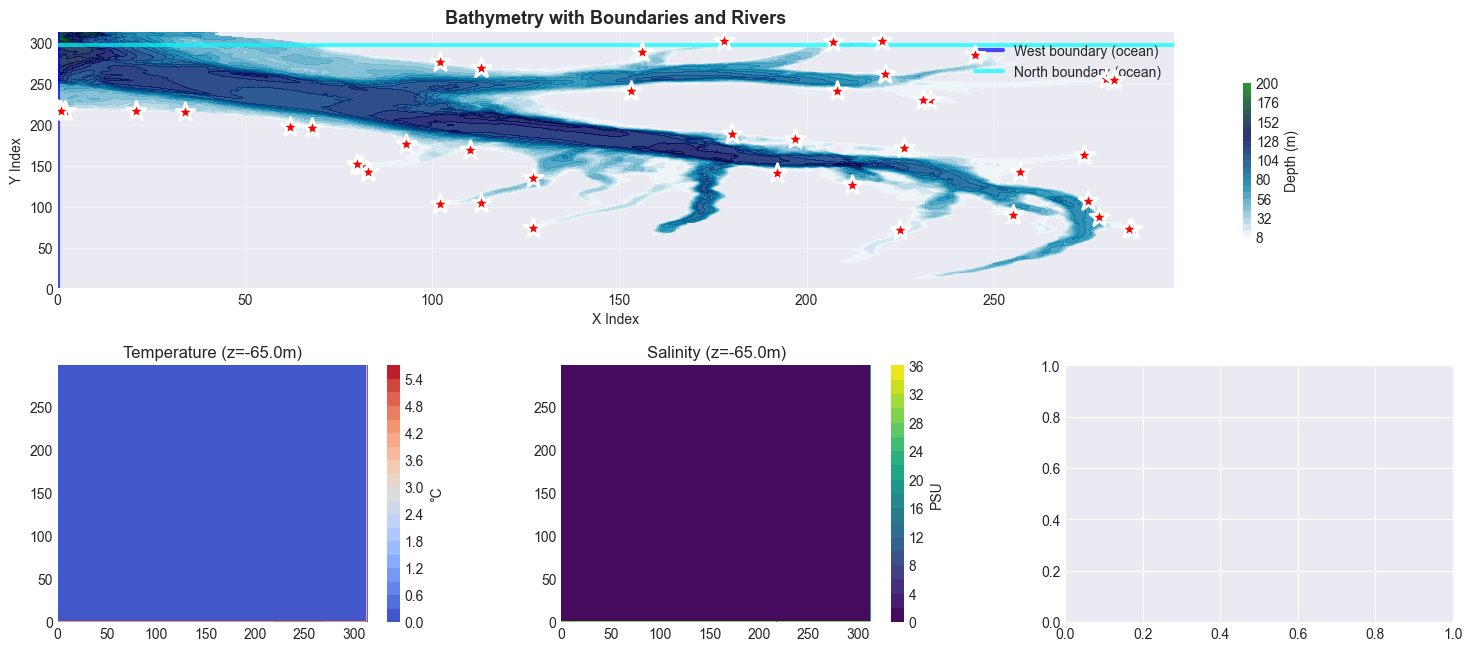

In [62]:
# Final summary plot
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Bathymetry with boundaries
ax1 = fig.add_subplot(gs[0, :])
cf = ax1.contourf(depth_plot, levels=25, cmap='ocean_r', alpha=0.8)
# Mark boundaries
ax1.axvline(x=0, color='blue', linewidth=3, label='West boundary (ocean)', alpha=0.7)
ax1.axhline(y=nx-1, color='cyan', linewidth=3, label='North boundary (ocean)', alpha=0.7)
# Mark rivers
for i, (name, x, y) in enumerate(zip(river_names, xrivers, yrivers)):
    ax1.scatter(y, x, c='red', s=200, marker='*', edgecolors='white', linewidths=2, zorder=10)
    #ax1.text(y+5, x, name.split('_')[1], fontsize=9, color='red', fontweight='bold',
    #       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.colorbar(cf, ax=ax1, label='Depth (m)', shrink=0.6)
ax1.set_title('Bathymetry with Boundaries and Rivers', fontsize=13, fontweight='bold')
ax1.set_xlabel('X Index')
ax1.set_ylabel('Y Index')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Boundary conditions at mid-year
t_idx = len(ds_verify.time) // 2

ax2 = fig.add_subplot(gs[1, 0])
im = ax2.contourf(ds_verify['T'].isel(time=t_idx, Nz=10).T, levels=20, cmap='coolwarm')
plt.colorbar(im, ax=ax2, label='°C')
ax2.set_title(f'Temperature (z={z_centers[10]:.1f}m)')

ax3 = fig.add_subplot(gs[1, 1])
im = ax3.contourf(ds_verify['S'].isel(time=t_idx, Nz=10).T, levels=20, cmap='viridis')
plt.colorbar(im, ax=ax3, label='PSU')
ax3.set_title(f'Salinity (z={z_centers[10]:.1f}m)')

ax4 = fig.add_subplot(gs[1, 2])
speed = np.sqrt(ds_verify['u'].isel(time=t_idx, Nz=10, Nx_faces=slice(0,-1)).T**2 + 
                ds_verify['v'].isel(time=t_idx, Nz=10, Ny_faces=slice(0,-1)).T**2)
im = ax4.contourf(speed, levels=20, cmap='plasma')
plt.colorbar(im, ax=ax4, label='m/s')
ax4.set_title(f'Current Speed (z={z_centers[10]:.1f}m)')

# Time series at boundary
ax5 = fig.add_subplot(gs[2, 0])
ds_verify['T'].isel(Nx=0, Ny=ny//2, Nz=10).plot(ax=ax5, color='red')
ax5.set_title('Temperature at West Boundary')
ax5.set_ylabel('Temperature (°C)')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[2, 1])
ds_verify['S'].isel(Nx=0, Ny=ny//2, Nz=10).plot(ax=ax6, color='blue')
ax6.set_title('Salinity at West Boundary')
ax6.set_ylabel('Salinity (PSU)')
ax6.grid(True, alpha=0.3)

ax7 = fig.add_subplot(gs[2, 2])
# Show river influence (salinity at river locations)
for i, (name, x, y) in enumerate(zip(river_names, xrivers, yrivers)):
    ds_verify['S'].isel(Nx=y, Ny=x, Nz=0).plot(ax=ax7, label=name.split('_')[1])
ax7.set_title('Salinity at River Inputs (surface)')
ax7.set_ylabel('Salinity (PSU)')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

plt.suptitle('Boundary Conditions Summary - Isafjardardju 299x315', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('Isf_BRY_299x315_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Summary visualization saved: Isf_BRY_299x315_summary.png")

## Summary

This notebook has created boundary condition files for the Isafjardardju simulation with:

### Grid Configuration
- **Dimensions**: 299 x 315 horizontal, 29 vertical layers
- **Bathymetry**: `Isafjardardjup_bathymetry299x315.nc`
- **Vertical grid**: Negative z-coordinates ordered from deepest (-190m) to surface (0m) - Oceananigans convention

### Boundary Conditions
1. **Ocean boundaries** (west and north edges):
   - Temperature, salinity, and velocity from CMEMS
   - 10-day relaxation timescale
   - Gaussian smoothing applied

2. **River inputs** (from WFS dataset):
   - Data source: `isafjardardjup_rivers_wfs.nc`
   - Number of rivers: Variable (all rivers with valid locations)
   - Freshwater input (salinity = 0)
   - Discharge-based relaxation coefficients
   - Grid locations automatically mapped

### Output File
- **Filename**: `Isf_bry_299x315.nc`
- **Variables**: T, S, u, v (with corresponding lambda coefficients)
- **Format**: NetCDF compatible with FjordsSim.jl

The file is ready for use with the `forcing_from_file` function in FjordsSim.jl.